# Problem Statement:

To develop a machine learning model that predicts the water quality index using water chemistry measurements.


The goal is to predict WQI for water
quality management.

# Dataset Description

[WQI Dataset](https://www.kaggle.com/datasets/seyedarmanhossaini/water-quality-index-wqi/data)

This dataset is created for predictive modeling and environmental analysis regarding Water Quality Index (WQI), and includes key physicochemical and microbiological parameters of water. The objective is to facilitate intelligent, interpretable, and scalable monitoring of water quality in natural resources.

Target Variable:
WQI (Water Quality Index)

Features:

Physicochemical: pH, Temperature, Dissolved Oxygen (DO), Biochemical Oxygen Demand (BOD), Conductivity, Nitrate, Phosphate, etc.

Microbiological: Fecal Coliform

Applications:

Training regression models (such as Random Forest and XGBoost) for predicting WQI

Feature importance analysis to identify key factors affecting water quality

Visualization and interpretation of environmental patterns

Source:

This dataset has been obtained from the Kaggle platform and has been pre-processed and cleaned for this analysis.

Use Cases:

Environmental monitoring agencies and water resource management

Smart water quality monitoring systems Research and education in environmental science and data science

# Importing the Dependencies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

#1. Data Preparation
Preparing the Data for the further use of Analysis & Prediction

## Read Data Files

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("seyedarmanhossaini/water-quality-index-wqi")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'water-quality-index-wqi' dataset.
Path to dataset files: /kaggle/input/water-quality-index-wqi


In [ ]:
wqi_df = pd.read_csv(path + "/Results_MADE.csv")

## Basic inspection

In [ ]:
# Checking the null values
wqi_df.isnull().sum()

,0
Temperature,0
Dissolved Oxygen,0
pH,0
Bio-Chemical Oxygen Demand (mg/L),0
Faecal Streptococci (MPN/ 100 mL),0
Nitrate (mg/ L),0
Faecal Coliform (MPN/ 100 mL),0
Total Coliform (MPN/ 100 mL),0
Conductivity (mho/ Cm),0
WQI,0


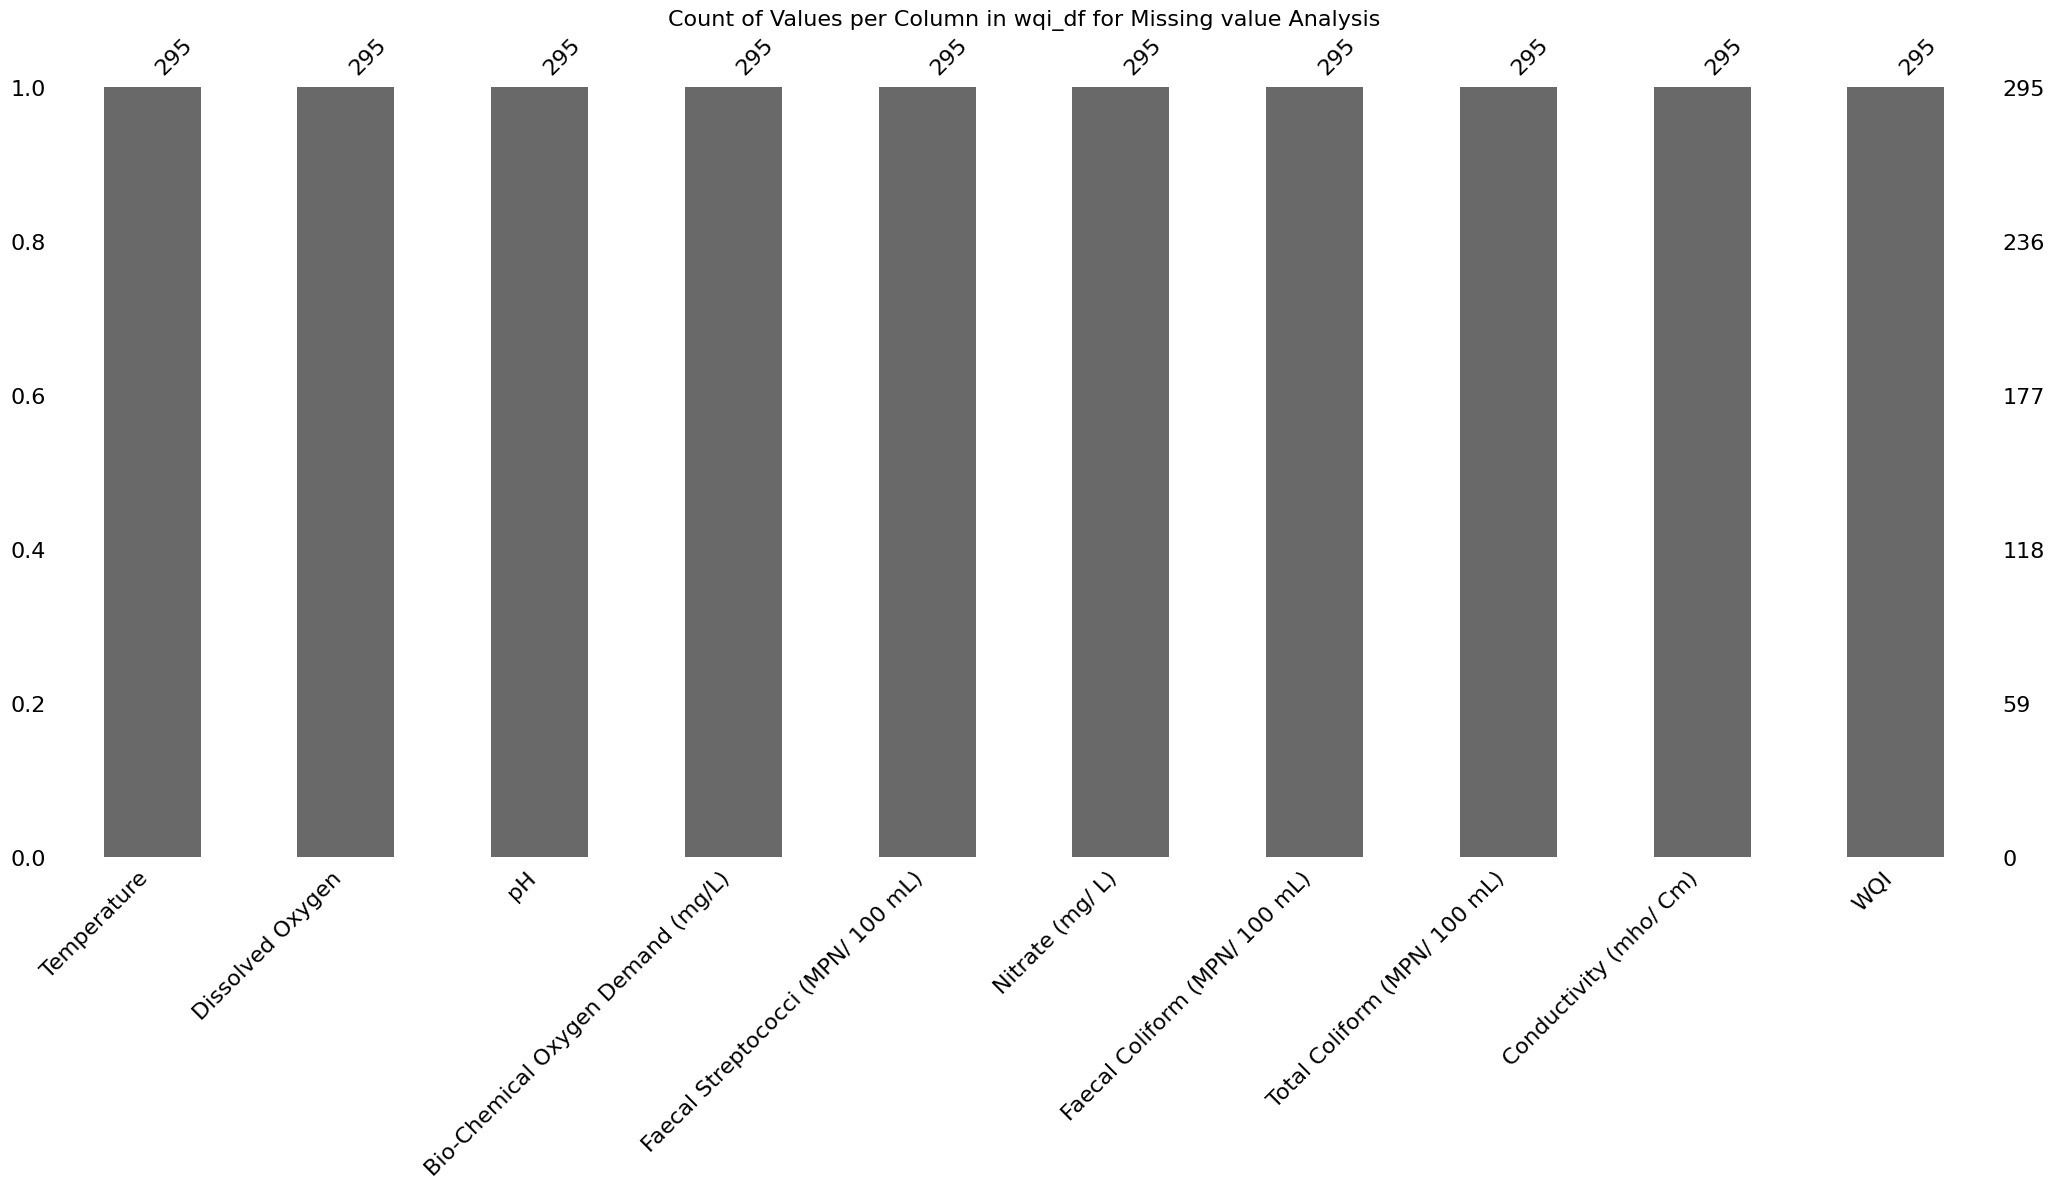

In [ ]:
import missingno as msno
msno.bar(wqi_df)
plt.title('Count of Values per Column in wqi_df for Missing value Analysis', size=16)
plt.show()

Since there is no missing values so we can move forward

In [ ]:
# Printing the Head of the dataset
wqi_df.head()

,Temperature,Dissolved Oxygen,pH,Bio-Chemical Oxygen Demand (mg/L),Faecal Streptococci (MPN/ 100 mL),Nitrate (mg/ L),Faecal Coliform (MPN/ 100 mL),Total Coliform (MPN/ 100 mL),Conductivity (mho/ Cm),WQI
0,7.5,9.95,7.85,0.15,90.0,0.255,22.5,180.0,134.5,27.143963
1,11.0,9.65,7.70,0.45,205.0,0.200,62.5,410.0,77.0,15.780001
2,7.5,9.90,7.65,0.55,100.0,0.100,26.0,200.0,101.5,20.612438
3,8.5,9.65,7.55,0.35,300.0,0.250,97.5,600.0,148.0,29.820475
4,10.0,9.55,7.80,0.25,190.0,0.150,47.5,380.0,106.0,21.498569


In [ ]:
wqi_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295 entries, 0 to 294
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Temperature                        295 non-null    float64
 1   Dissolved Oxygen                   295 non-null    float64
 2   pH                                 295 non-null    float64
 3   Bio-Chemical Oxygen Demand (mg/L)  295 non-null    float64
 4   Faecal Streptococci (MPN/ 100 mL)  295 non-null    float64
 5   Nitrate (mg/ L)                    295 non-null    float64
 6   Faecal Coliform (MPN/ 100 mL)      295 non-null    float64
 7   Total Coliform (MPN/ 100 mL)       295 non-null    float64
 8   Conductivity (mho/ Cm)             295 non-null    float64
 9   WQI                                295 non-null    float64
dtypes: float64(10)
memory usage: 23.2 KB


Since all of these values are numerics

## Remove Duplicates

In [ ]:
# Checking the duplicates
wqi_df.duplicated().sum()

np.int64(0)

In [ ]:
wqi_df.shape

(295, 10)

Since this is a very small dataset having only 295 rows

# 2: Exploratory Data Analysis

In [ ]:
wqi_df.describe()

,Temperature,Dissolved Oxygen,pH,Bio-Chemical Oxygen Demand (mg/L),Faecal Streptococci (MPN/ 100 mL),Nitrate (mg/ L),Faecal Coliform (MPN/ 100 mL),Total Coliform (MPN/ 100 mL),Conductivity (mho/ Cm),WQI
count,295.000000,295.000000,295.000000,295.000000,295.000000,295.000000,295.000000,295.000000,295.000000,295.000000
mean,20.903898,7.342034,7.754627,3.544136,7463.333729,0.870915,5983.661695,14926.667458,501.860678,100.889437
std,6.051566,1.910113,0.378879,9.043299,26272.135186,1.431247,22934.986514,52544.270371,798.311280,158.115301
min,0.000000,0.000000,5.350000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.524595
25%,18.000000,6.850000,7.550000,0.725000,29.225000,0.155000,4.000000,58.450000,208.250000,42.010910
50%,22.500000,7.750000,7.750000,1.600000,240.000000,0.550000,79.500000,480.000000,299.500000,60.379172
75%,25.550000,8.600000,8.000000,3.100000,2650.000000,0.950000,2375.000000,5300.000000,438.250000,90.120883
max,30.500000,10.250000,8.600000,123.500000,229000.000000,14.050000,251000.000000,458000.000000,9272.000000,1834.549110


## Distribution of WQI

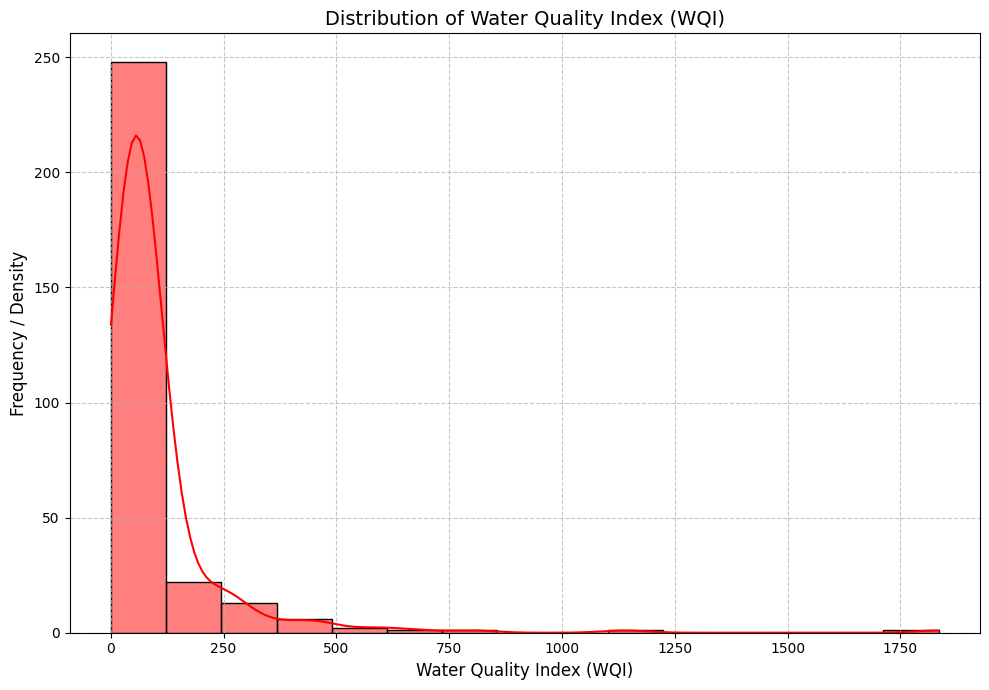

In [ ]:
plt.figure(figsize=(10, 7))
sns.histplot(wqi_df['WQI'], kde=True, bins=15, color='red', edgecolor='black')
plt.title("Distribution of Water Quality Index (WQI)", fontsize=14)
plt.xlabel("Water Quality Index (WQI)", fontsize=12)
plt.ylabel("Frequency / Density", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The Distribution of WQI is right skewed having lesser values

## Distribution of Features

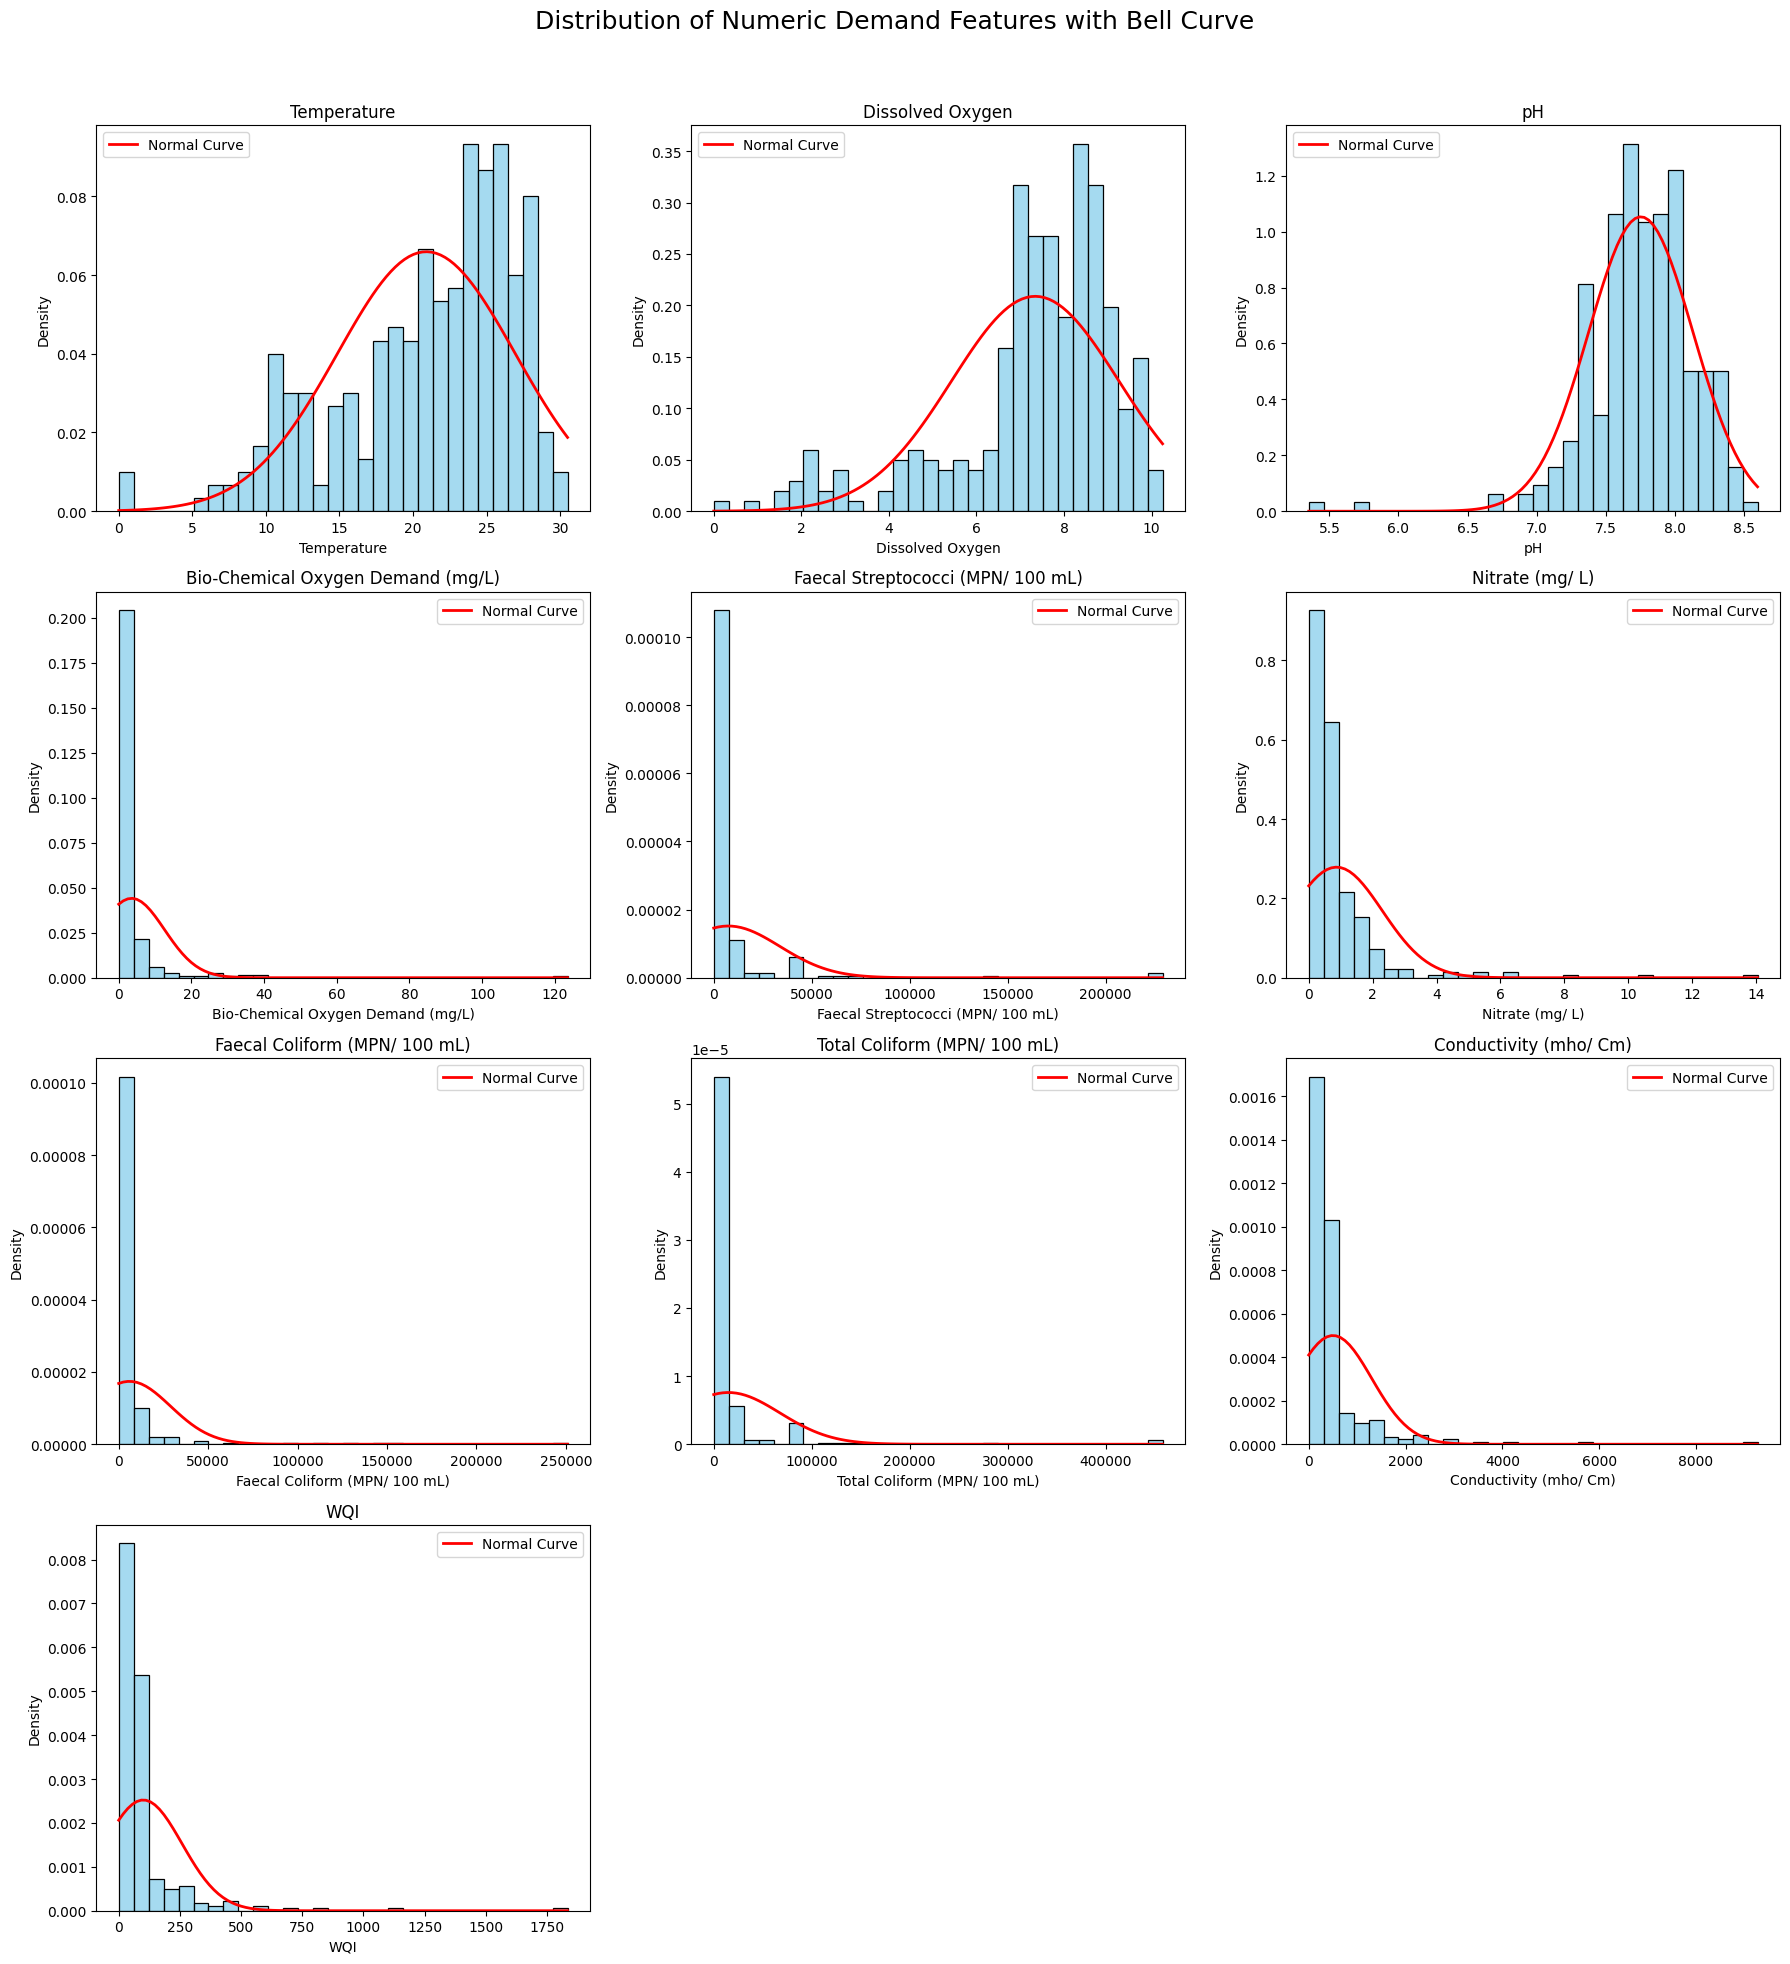

In [ ]:
# Histograms
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm

# Select only numeric features
numeric_cols = wqi_df.select_dtypes(include=np.number).columns

# Determine subplot grid size
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    data = wqi_df[col].dropna()

    # Histogram (density)
    sns.histplot(data, bins=30, stat='density', color='skyblue', edgecolor='black')

    # Overlay bell curve (normal distribution using mean and std)
    mu, std = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 100)
    plt.plot(x, norm.pdf(x, mu, std), color='red', lw=2, label='Normal Curve')

    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()

plt.suptitle("Distribution of Numeric Demand Features with Bell Curve", fontsize=18)
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()
plt.close()


## Box Plot

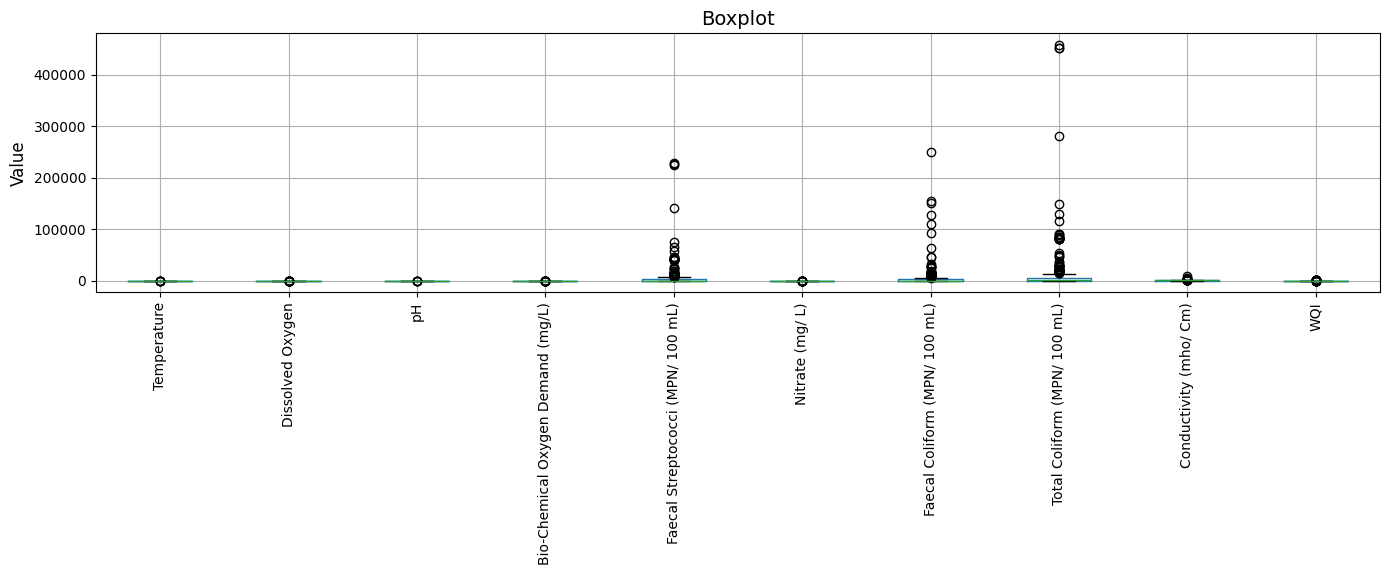

In [ ]:
plt.figure(figsize=(14, 6))
wqi_df[numeric_cols].boxplot(rot=90, grid=True, figsize=(14, 6))
plt.title("Boxplot", fontsize=14)
plt.ylabel("Value", fontsize=12)
plt.suptitle("")
plt.tight_layout()
plt.show()

Since there are some outliers which needs to be removed

## Pairplot

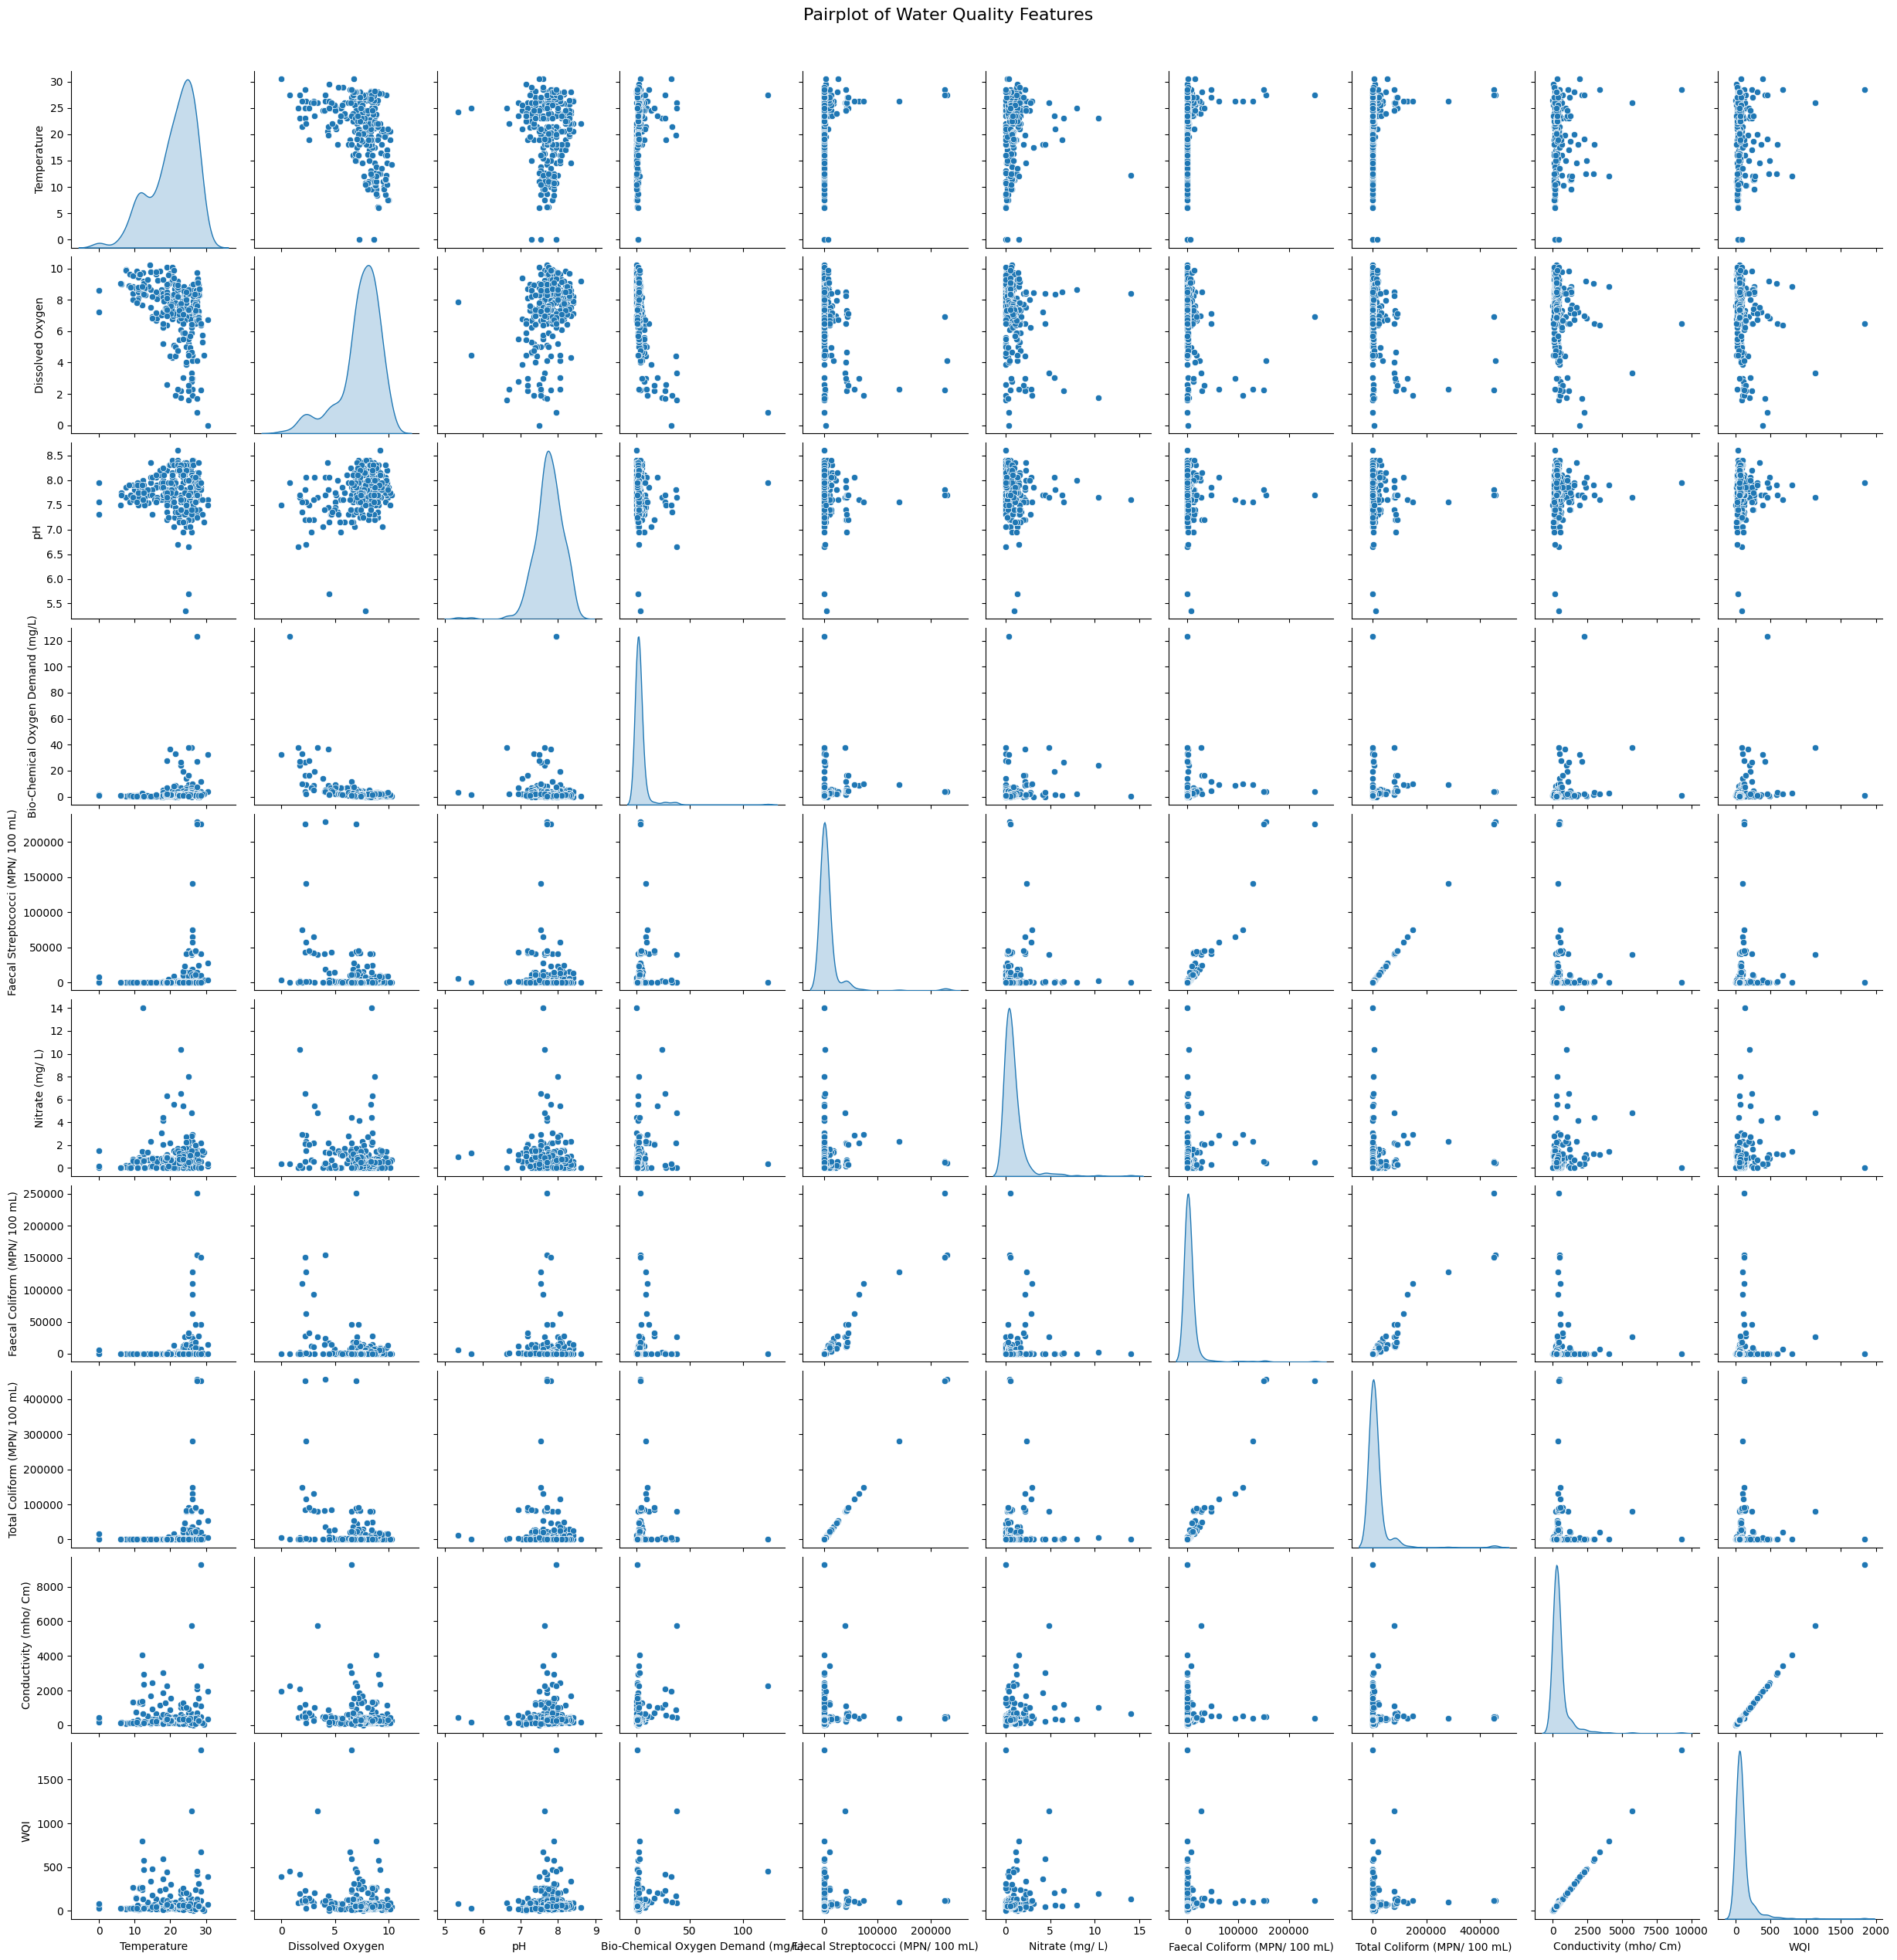

In [ ]:
# pairplot
sns.pairplot(wqi_df, diag_kind='kde', height=2.5)
plt.suptitle("Pairplot of Water Quality Features", y=1.02, fontsize=16)
plt.show()

## Correlation Heatmap

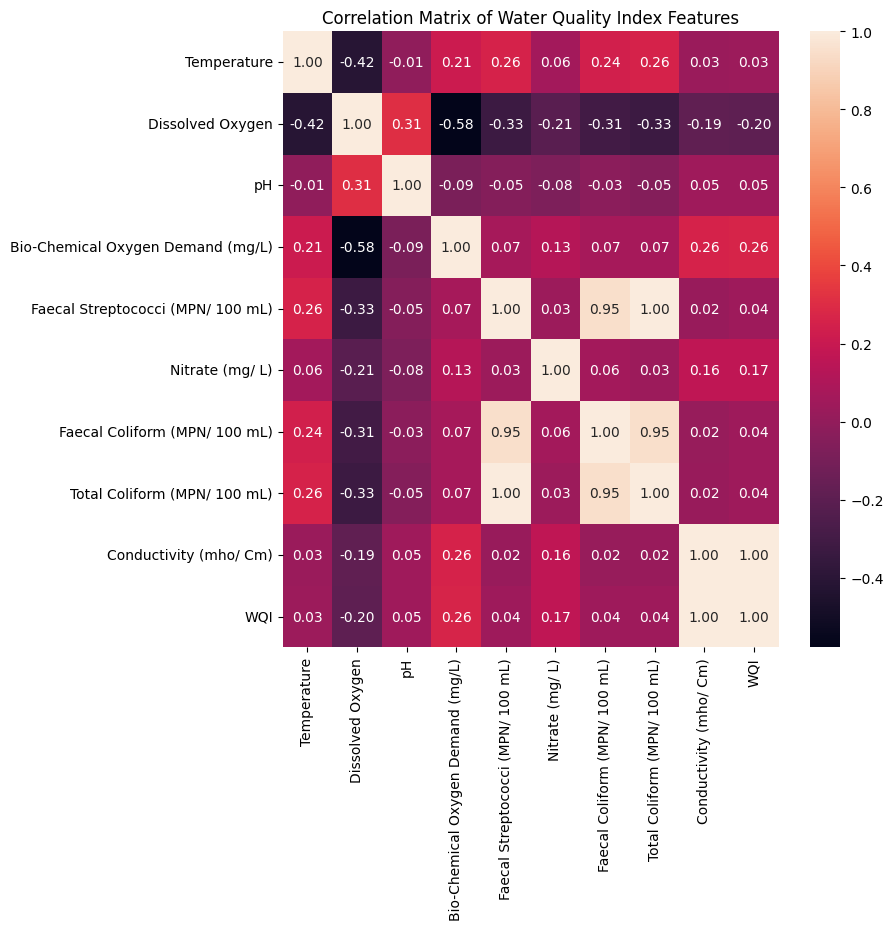

In [ ]:
plt.figure(figsize=(8, 8))
sns.heatmap(wqi_df.corr(), annot=True, fmt='.2f')
plt.title('Correlation Matrix of Water Quality Index Features')
plt.show()

The Conductivity is 100% correlated to the WQI while the other features shows moderate or negative correlation

## Top features by correaltion

In [ ]:
corr = wqi_df.corr()
corr_with_wqi = corr['WQI'].sort_values(ascending=False).drop(['WQI'])
corr_with_wqi

,WQI
Conductivity (mho/ Cm),0.999743
Bio-Chemical Oxygen Demand (mg/L),0.261980
Nitrate (mg/ L),0.165180
pH,0.046825
Faecal Streptococci (MPN/ 100 mL),0.044002
Total Coliform (MPN/ 100 mL),0.044002
Faecal Coliform (MPN/ 100 mL),0.038203
Temperature,0.034991
Dissolved Oxygen,-0.195878


/tmp/ipykernel_311/1827732683.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_wqi.index, y=corr_with_wqi.values, palette='viridis')


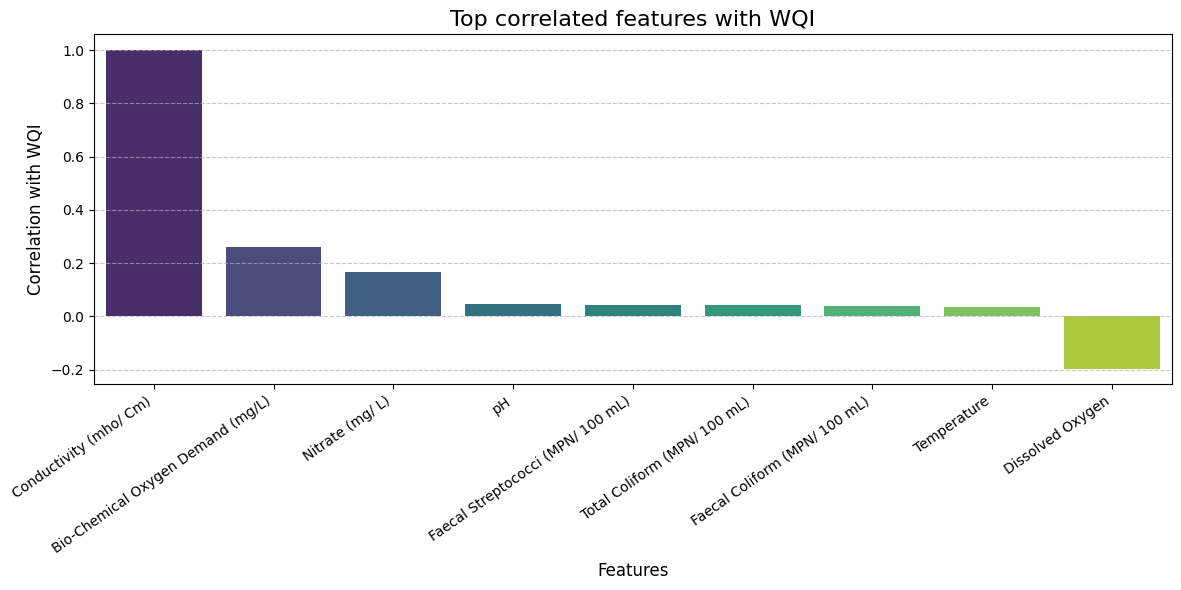

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x=corr_with_wqi.index, y=corr_with_wqi.values, palette='viridis')
plt.title('Top correlated features with WQI', fontsize=16)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Correlation with WQI', fontsize=12)
plt.xticks(rotation=35, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#3: Transform Data

## Outliers Removal Using IQR Method

In [ ]:
def cap_outliers_iqr_with_median(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    median_val = df[column].median()

    df[column] = np.where(df[column] < lower_bound, median_val, df[column])
    df[column] = np.where(df[column] > upper_bound, median_val, df[column])
    return df

In [ ]:
for col in wqi_df.columns:
    wqi_df = cap_outliers_iqr_with_median(wqi_df, col)

## Distribution of WQI after outliers removal

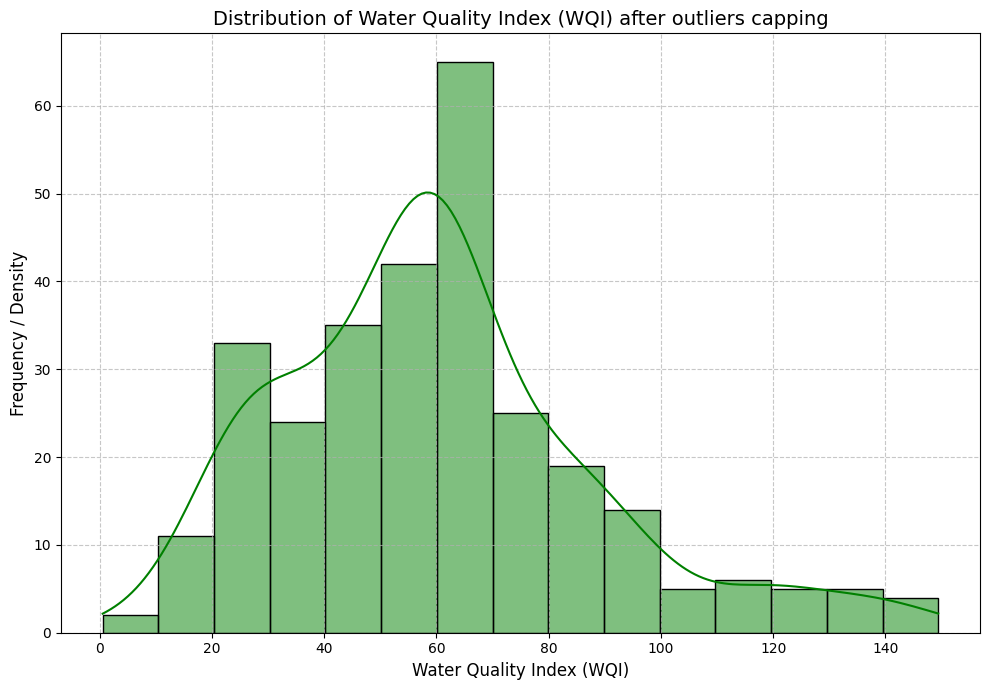

In [ ]:
plt.figure(figsize=(10, 7))
sns.histplot(wqi_df['WQI'], kde=True, bins=15, color='green', edgecolor='black')
plt.title("Distribution of Water Quality Index (WQI) after outliers capping", fontsize=14)
plt.xlabel("Water Quality Index (WQI)", fontsize=12)
plt.ylabel("Frequency / Density", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Distribution of Features after outliers removal

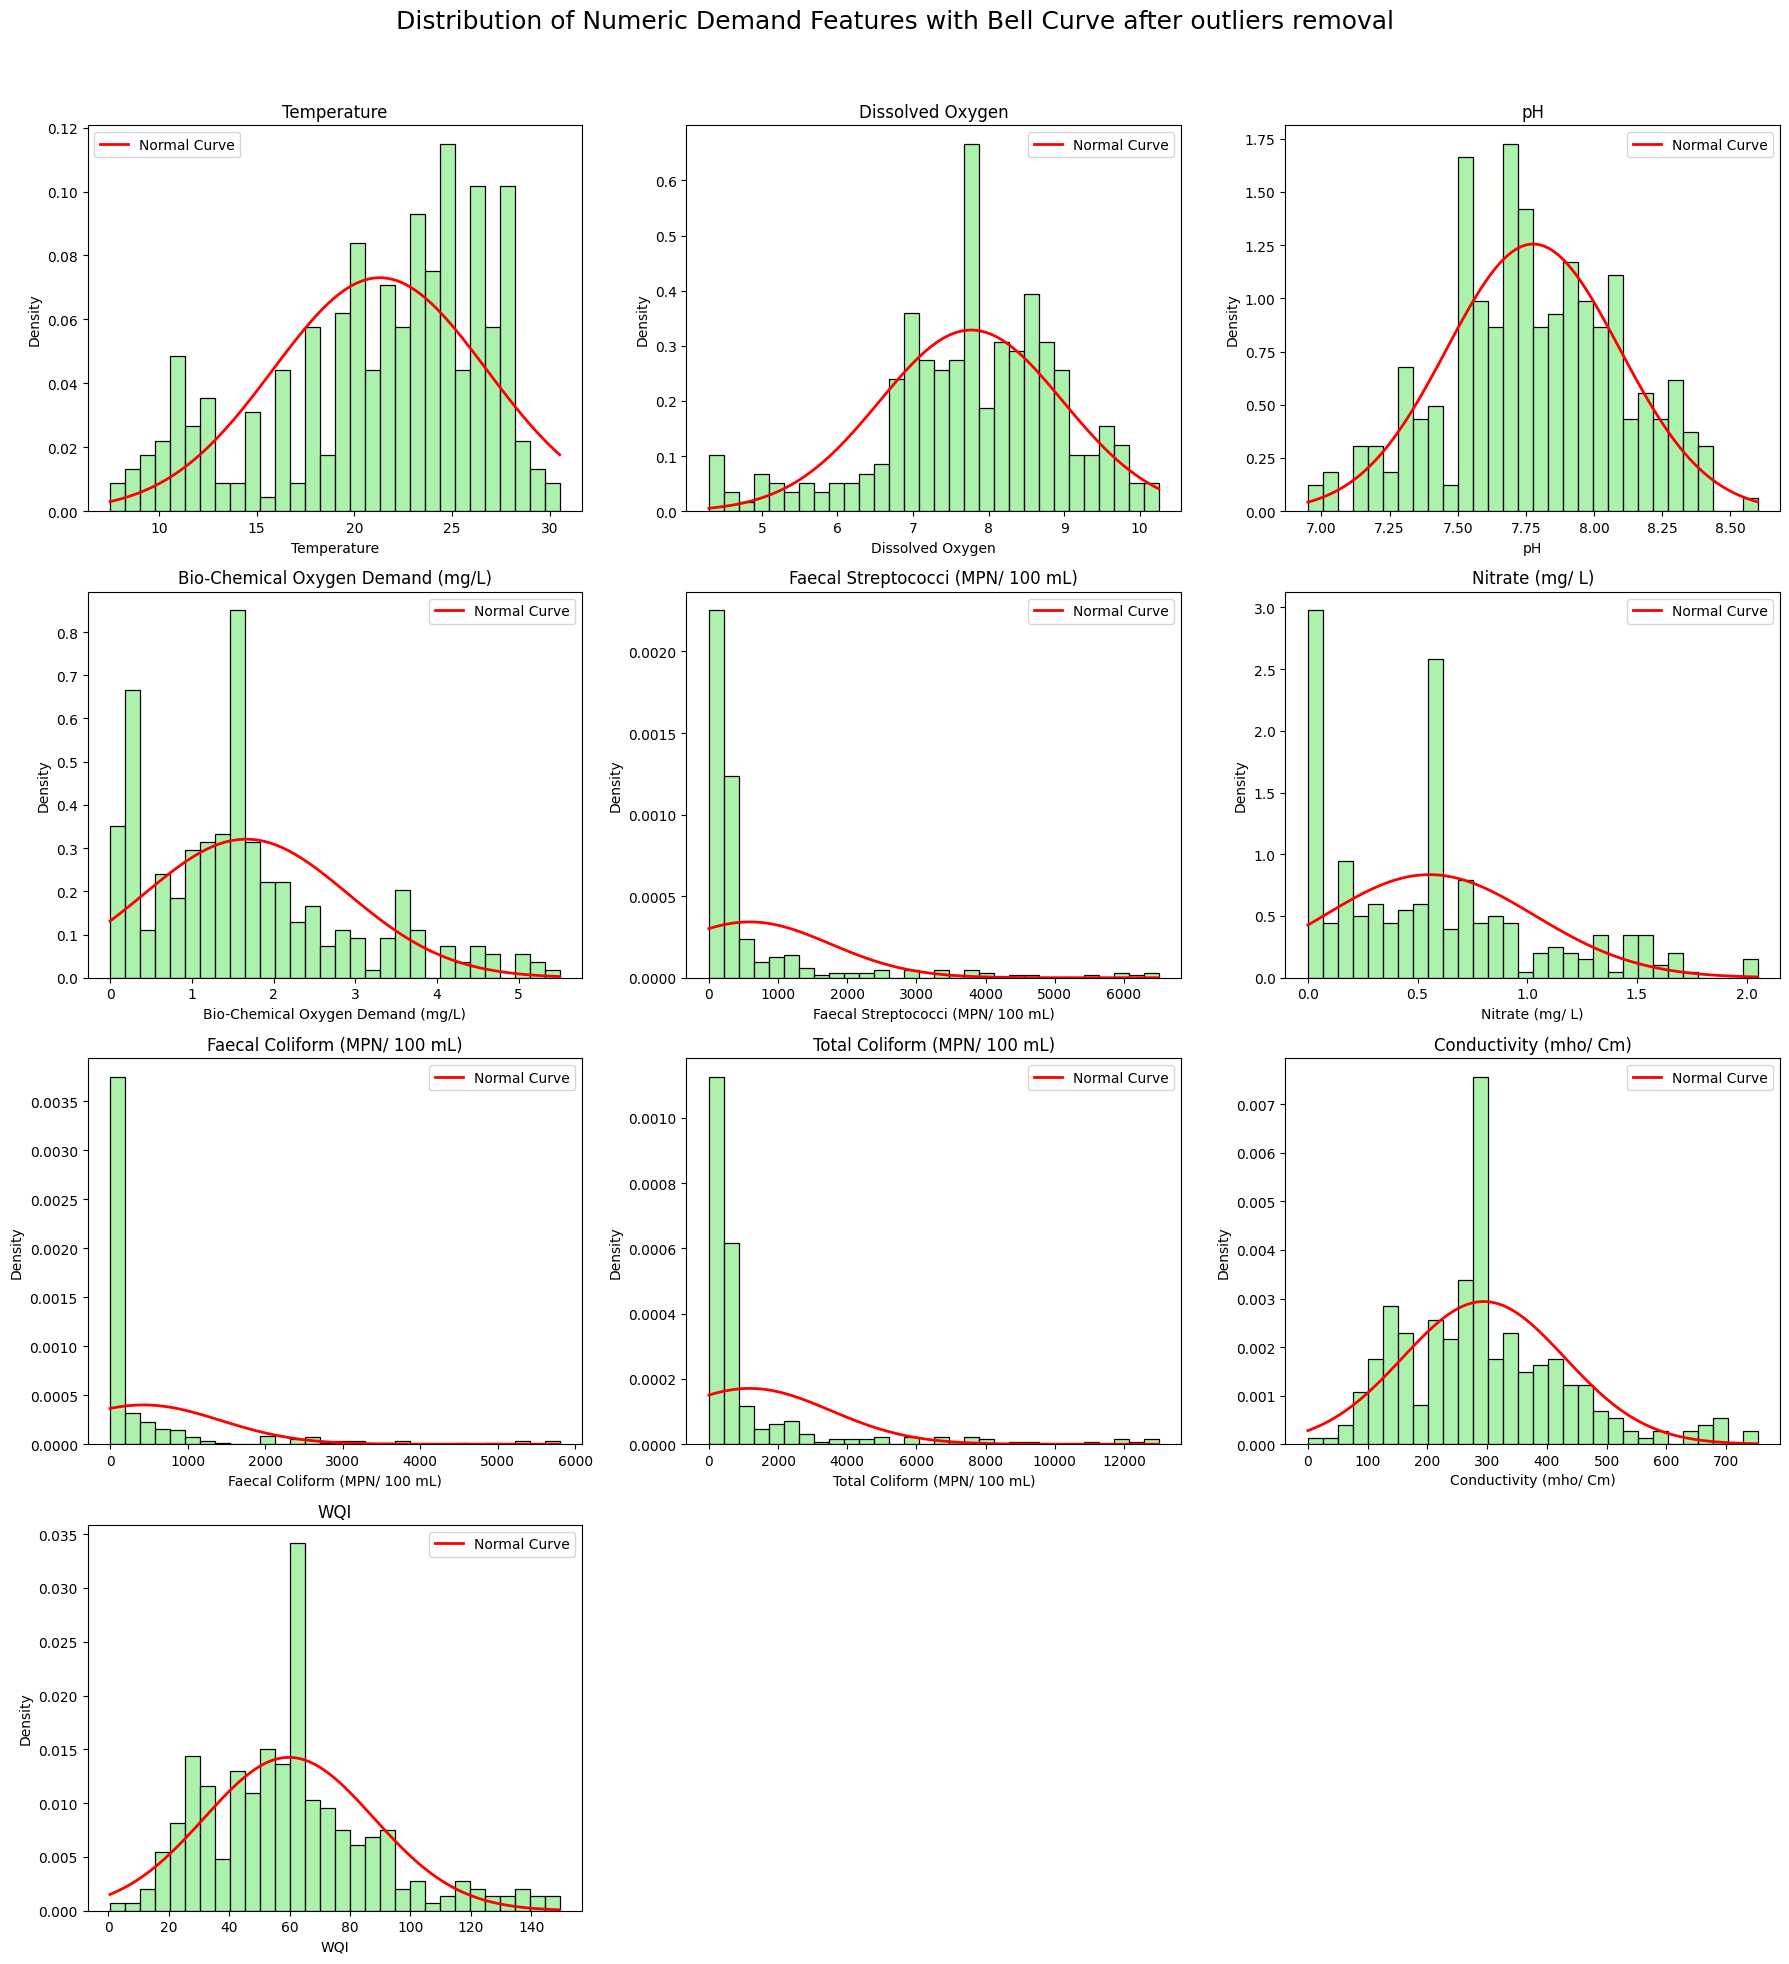

In [ ]:
# Histograms
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm

# Select only numeric features
numeric_cols = wqi_df.select_dtypes(include=np.number).columns

# Determine subplot grid size
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    data = wqi_df[col].dropna()

    # Histogram (density)
    sns.histplot(data, bins=30, stat='density', color='lightgreen', edgecolor='black')

    # Overlay bell curve (normal distribution using mean and std)
    mu, std = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 100)
    plt.plot(x, norm.pdf(x, mu, std), color='red', lw=2, label='Normal Curve')

    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()

plt.suptitle("Distribution of Numeric Demand Features with Bell Curve after outliers removal", fontsize=18)
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()
plt.close()

##  Splitting the Features & Target variable

In [ ]:
X = wqi_df.drop('WQI', axis=1)
y = wqi_df['WQI']

## Splitting the Data into Training & Testing

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (236, 9)
X_test shape: (59, 9)
y_train shape: (236,)
y_test shape: (59,)


## Feature Scaling

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

We use standard scaler because we have values ranging from too high numerics values

# 4:  ML Model Fitting

## Training a Regression Model

Using Linear Regression, Decision Tree Regressor, Random Forest Regressor, SVR & KNN Regressor and Gradient Boosting Regressor then selecting best based on MSE & R2 score

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(random_state=42),
    "Support Vector Regressor": SVR(),
    "K-Nearest Neighbors Regressor": KNeighborsRegressor(),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42)
}

In [ ]:
results = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        "mse": mse,
        "r2_score": r2
    }
    print(f"{name} - Mean Squared Error: {mse:.4f}, R-squared: {r2:.4f}\n")
    print("--"*50)

Training Linear Regression...
Linear Regression - Mean Squared Error: 4.7834, R-squared: 0.9916

----------------------------------------------------------------------------------------------------
Training Decision Tree Regressor...
Decision Tree Regressor - Mean Squared Error: 66.0134, R-squared: 0.8840

----------------------------------------------------------------------------------------------------
Training Random Forest Regressor...
Random Forest Regressor - Mean Squared Error: 13.1203, R-squared: 0.9770

----------------------------------------------------------------------------------------------------
Training Support Vector Regressor...
Support Vector Regressor - Mean Squared Error: 259.2709, R-squared: 0.5445

----------------------------------------------------------------------------------------------------
Training K-Nearest Neighbors Regressor...
K-Nearest Neighbors Regressor - Mean Squared Error: 123.5709, R-squared: 0.7829

-------------------------------------------

Since the linear regression is the best model for this dataset

## Models Comparision

In [ ]:
model_performance_df = pd.DataFrame.from_dict(results, orient='index')
model_performance_df.index.name = 'Model'
model_performance_df.rename(columns={'mse': 'MSE', 'r2_score': 'R2 Score'}, inplace=True)
model_performance_df = model_performance_df.sort_values(by='R2 Score', ascending=False)

print("Model Performance Summary:")
print(model_performance_df)

Model Performance Summary:
                                      MSE  R2 Score
Model                                              
Linear Regression                4.783432  0.991596
Random Forest Regressor         13.120274  0.976950
Gradient Boosting Regressor     14.328819  0.974827
Decision Tree Regressor         66.013364  0.884028
K-Nearest Neighbors Regressor  123.570901  0.782910
Support Vector Regressor       259.270885  0.544512


### According to MSE

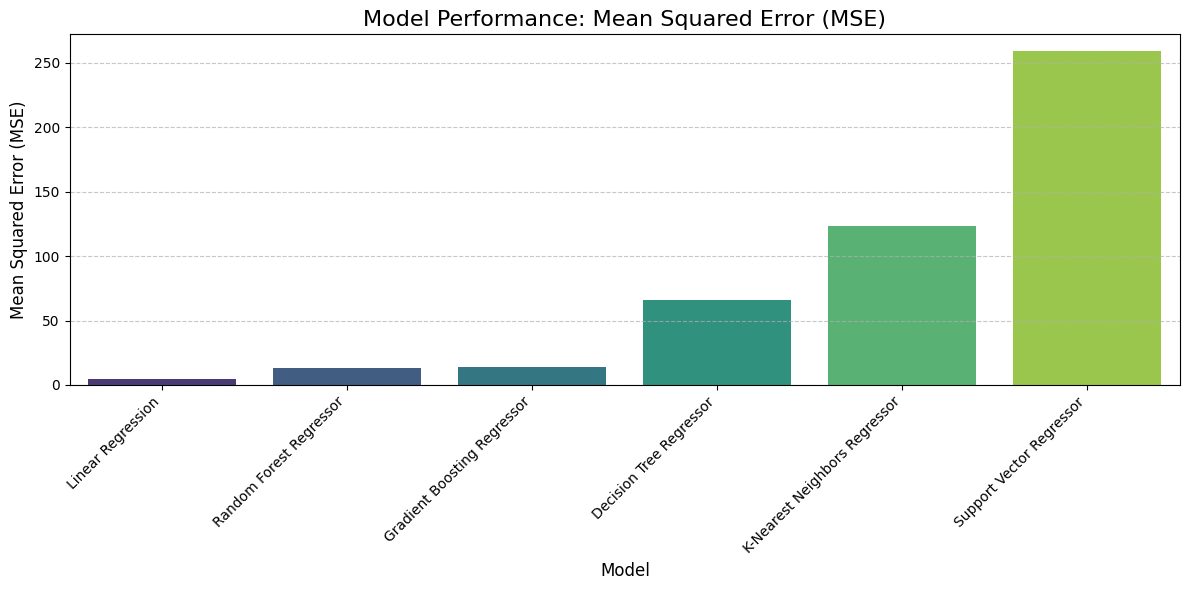

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x=model_performance_df.index, y=model_performance_df['MSE'], palette='viridis', hue=model_performance_df.index, legend=False)
plt.title('Model Performance: Mean Squared Error (MSE)', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### According to R2-Score

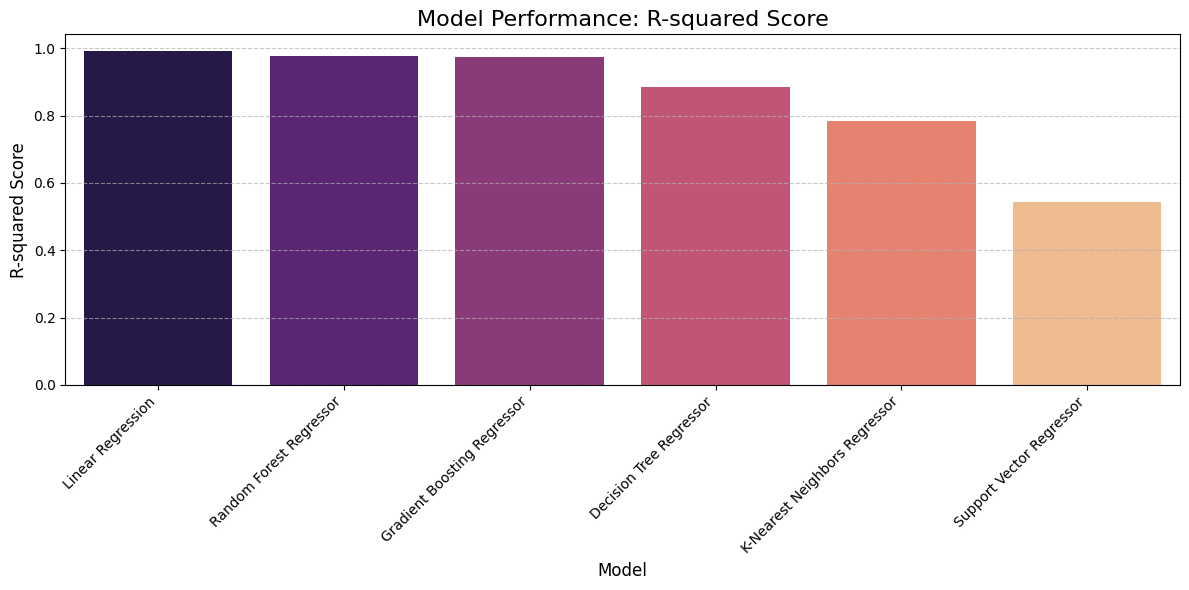

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x=model_performance_df.index, y=model_performance_df['R2 Score'], palette='magma', hue=model_performance_df.index, legend=False)
plt.title('Model Performance: R-squared Score', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('R-squared Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Since the Linear Regression will be the best fit for this dataset**